## Tarefa

In [31]:
import numpy as np

## 1

In [32]:
def f_x(x):
    valor = 1 / (x ** 4)
    print(f"f({x}) = {valor}")

### Calculando valores para gerar o sistema

$ <f, g> = \int_{0}^{1} x^2 f(x) g(x) dx $

$ <x^2, x^2> = \int_{0}^{1} x^2 x^2 x^2 dx = \int_{0}^{1} x^6, dx = \frac{x^7}{7} [0, 1] = \frac{1}{7}$

$ <x^2, x^4> = \int_{0}^{1} x^8 dx = \frac{x^9}{9} [0,1] = \frac{1}{9} $

$ <x^4, x^2> = <x^2, x^4> $

$ <x^4, x^4> = \int_{0}^{1} x^{10} dx = \frac{x^{11}}{11} [0, 1]= \frac{1}{11} $

$ <f, x^2> = \int_{0}^{1} x^2 \frac{1}{x^4} x^2 dx  = \int_{0}^{1} 1  dx = x [0, 1] = 1 $

$ <f, x^4> = \int_{0}^{1} x^2 \frac{1}{x^4} x^4 dx = \int_{0}^{1} x^2 dx = \frac{x^3}{3} [0, 1] = \frac{1}{3}$ 

In [33]:
matriz = np.array([[1/7, 1/9],
                  [1/9, 1/11]])

resultados = np.array([[1.],
                      [1/3]])

coefs = np.linalg.solve(matriz, resultados)

print(coefs)


[[ 84.]
 [-99.]]


In [34]:
def polinomio(coefs, x):
    valor = coefs[0] * x ** 2 + coefs[1] * x ** 4
    print(f"P({x}) = {valor}")

### Calculando f(0.4), P(0.4), f(0.9) e P(0.9)

In [35]:
polinomio(coefs, 0.4)
f_x(0.4)

polinomio(coefs, 0.9)
f_x(0.9)

P(0.4) = [10.9056]
f(0.4) = 39.06249999999999
P(0.9) = [3.0861]
f(0.9) = 1.5241579027587258


### Conclusões

O polinômio não foi preciso ao usar $ x = 0.4 $, porém com $x = 0.9$, a diferença foi bem menor. Essa diferença (para $ x = 0.4 $) ocorre principalmente por causa da função $ f(x) = \frac{1}{x^4} $ que cresce muito rápido usando valores de x próximos de zero, então o polinômio não consegue repetir o comportamento. A medida que x cresce, a diferença entre a f(x) e P(x) diminui.

## 2

In [36]:
import matplotlib.pyplot as plt

In [37]:
xi = np.array([-3., -1, 1, 2, 3])
yi = np.array([-1., 0, 1, 1, -1])

In [38]:
def parabola(coefs, x):
    return coefs[0] + coefs[1] * x + coefs[2] * x ** 2

def polinomio_incompleto(coefs, x):
    return coefs[0] * x + coefs[1] * x ** 3

In [39]:
u1 = np.zeros((5, 3))

u1[:, 0] = 1
u1[:, 1] = xi
u1[:, 2] = xi ** 2


f1 = np.zeros(3)
f1[0] = np.sum(yi * u1[:, 0])
f1[1] = np.sum(yi * u1[:, 1])
f1[2] = np.sum(yi * u1[:, 2])

u1 = u1.T @ u1

coefs1 = np.linalg.solve(u1, f1)

print(u1)
print(f1)

print(f"Polinômio (parábola): {coefs1[0]:.2f} + {coefs1[1]:.2f}x + {coefs1[2]:.2f} x^2")

[[  5.   2.  24.]
 [  2.  24.   8.]
 [ 24.   8. 180.]]
[  0.   3. -13.]
Polinômio (parábola): 0.90 + 0.12x + -0.20 x^2


In [40]:
u2 = np.zeros((5, 2))

u2[:, 0] = xi
u2[:, 1] = xi ** 3

f2 = np.zeros(2)

f2[0] = np.sum(yi * u2[:, 0])
f2[1] = np.sum(yi * u2[:, 1])


u2 = u2.T @ u2

coefs2 = np.linalg.solve(u2, f2)

print(u2)
print(f2)

print(f"Polinômio: {coefs2[0]:.2f}x + {coefs2[1]:.2f}x^3")


[[  24.  180.]
 [ 180. 1524.]]
[3. 9.]
Polinômio: 0.71x + -0.08x^3


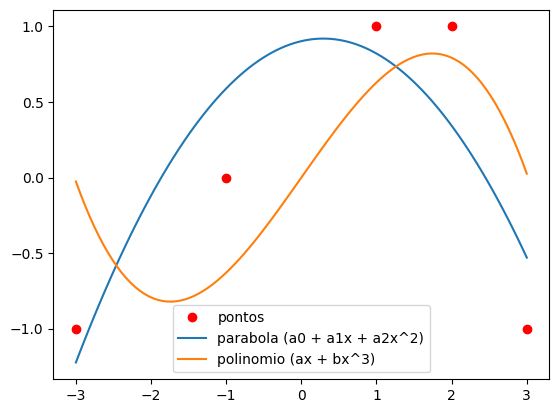

In [45]:
x = np.linspace(xi[0], xi[4], 100)
y1 = np.zeros(100)
y2 = np.zeros(100)

for i in range (0, 100):
    y1[i] = parabola(coefs1, x[i])
    y2[i] = polinomio_incompleto(coefs2, x[i])

plt.plot(xi, yi, 'ro', label='pontos')
plt.plot(x, y1, label='parabola (a0 + a1x + a2x^2)')
plt.plot(x, y2, label='polinomio (ax + bx^3)')
plt.legend()
plt.show()